In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('Sales_dataset.xlsx')

print(df.head())

   Order ID           Order Date Order Priority  Order Quantity      Sales  \
0      4387           10/22/2011       Critical               4   640.2100   
1     35875            6/14/2011           High              31   348.9200   
2      8768            8/18/2011           High              44  2422.4405   
3      2467            7/15/2011  Not Specified              30  4147.4700   
4     36675  2011-03-07 00:00:00           High              39   113.0900   

        Ship Mode  Shipping Cost          Province Customer Segment  \
0  Delivery Truck          39.25           Ontario        Corporate   
1     Regular Air           3.37  British Columbia        Corporate   
2     Regular Air           5.31           Alberta   Small Business   
3  Delivery Truck          17.85            Quebec        Corporate   
4     Regular Air           0.81           Ontario   Small Business   

  Product Category           Product Sub-Category Product Container  \
0        Furniture               

In [3]:
print(df.shape)

print(df.columns)

(222, 13)
Index(['Order ID', 'Order Date', 'Order Priority', 'Order Quantity', 'Sales',
       'Ship Mode', 'Shipping Cost', 'Province', 'Customer Segment',
       'Product Category', 'Product Sub-Category', 'Product Container',
       'Ship Date'],
      dtype='object')


In [4]:
df = df.drop_duplicates()

df['Order Date'] = pd.to_datetime(df['Order Date'])

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order ID              222 non-null    int64         
 1   Order Date            222 non-null    datetime64[ns]
 2   Order Priority        222 non-null    object        
 3   Order Quantity        222 non-null    int64         
 4   Sales                 222 non-null    float64       
 5   Ship Mode             222 non-null    object        
 6   Shipping Cost         222 non-null    float64       
 7   Province              222 non-null    object        
 8   Customer Segment      222 non-null    object        
 9   Product Category      222 non-null    object        
 10  Product Sub-Category  222 non-null    object        
 11  Product Container     222 non-null    object        
 12  Ship Date             222 non-null    object        
dtypes: datetime64[ns](1)

In [5]:
print("Total Sales:", df['Sales'].sum())

print("Average Sales:", df['Sales'].mean())

print("Maximum Sales:", df['Sales'].max())

print("Minimum Sales:", df['Sales'].min())

print("Total Orders:", df['Order ID'].nunique())

Total Sales: 323354.9775
Average Sales: 1456.5539527027026
Maximum Sales: 21555.6
Minimum Sales: 7.98
Total Orders: 210


Product Category
Technology         140961.3575
Furniture          110151.5300
Office Supplies     72242.0900
Name: Sales, dtype: float64


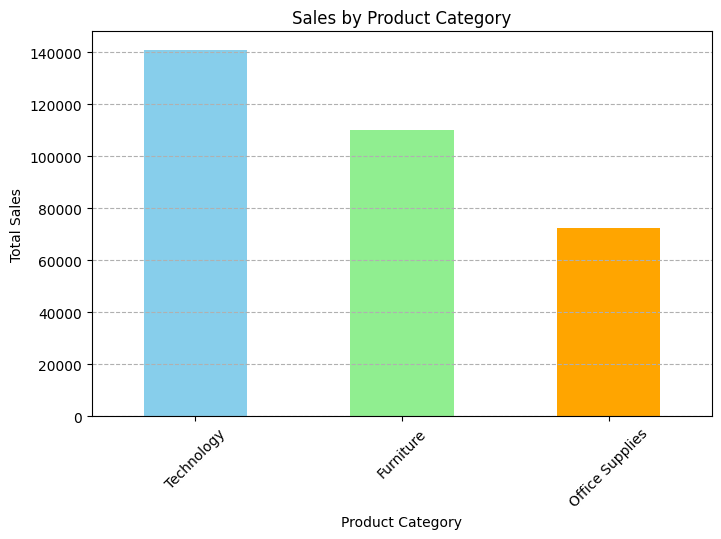

In [6]:
category_sales = df.groupby('Product Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

category_sales.plot(
    kind='bar',
    figsize=(8,5),
    color=['skyblue', 'lightgreen', 'orange']
)

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

plt.show()

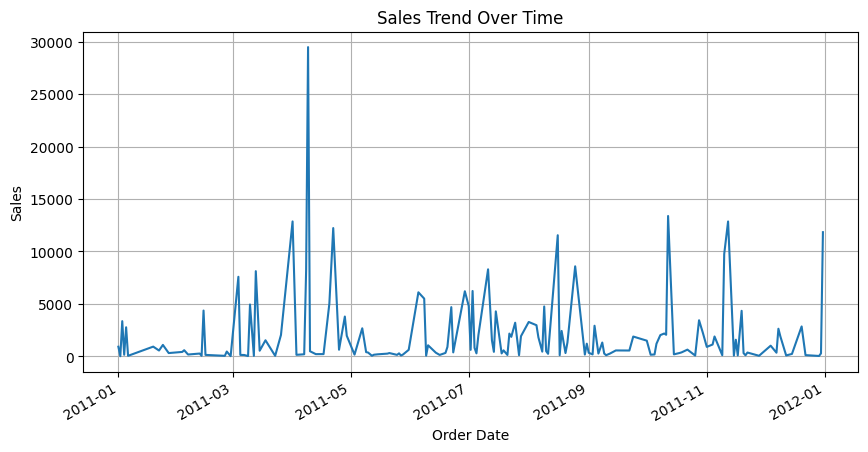

In [7]:
monthly_sales = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()

plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

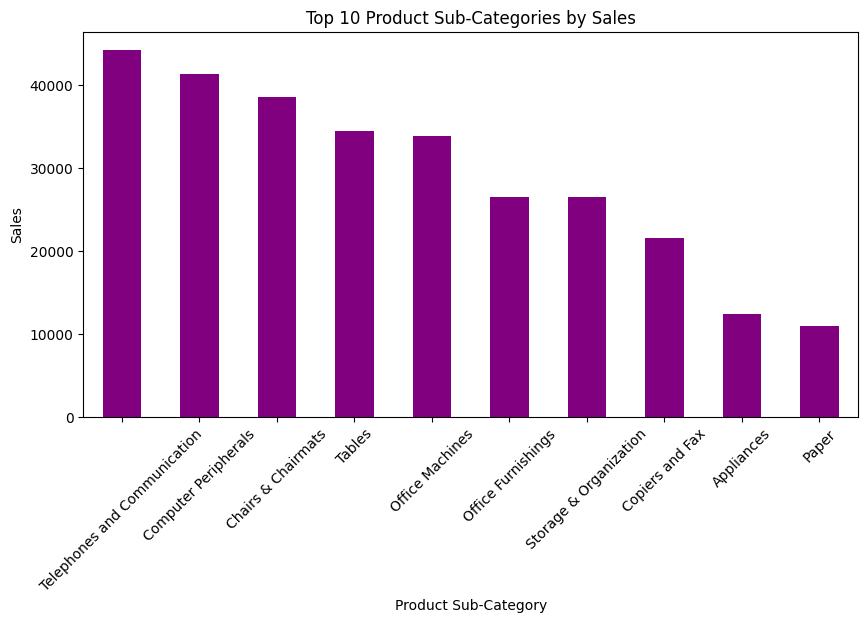

In [8]:
top_products = df.groupby('Product Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(
    kind='bar',
    figsize=(10,5),
    color='purple'
)

plt.title("Top 10 Product Sub-Categories by Sales")
plt.xlabel("Product Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

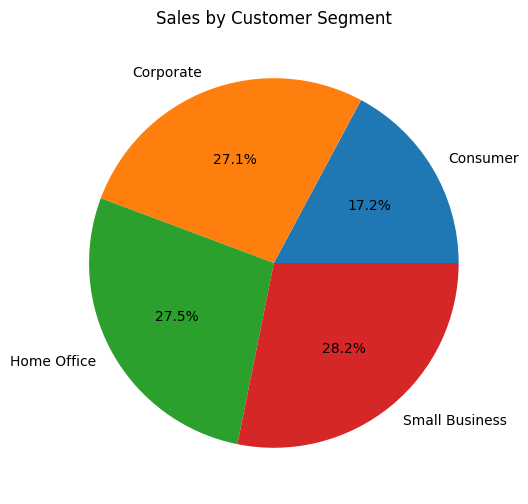

In [9]:
segment_sales = df.groupby('Customer Segment')['Sales'].sum()

segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Sales by Customer Segment")
plt.ylabel("")

plt.show()